<a href="https://colab.research.google.com/github/ruudtje21/ai-sql-assistant/blob/main/korosi_detection_yolov12_fasterrcnn_torchvision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Stabilitas Indikator Kerusakan Korosi
## Perbandingan YOLOv12 vs Faster R-CNN pada Kondisi Degradasi Citra

**Nama**  : Rudi Sumantri  
**NIM**   : 241012000065  
**Prodi** : Magister Teknik Informatika - Universitas Pamulang  

---

### Desain Penelitian
| Model | Framework | Data Training | Keterangan |
|-------|-----------|---------------|------------|
| yolo_A | YOLOv12n | Normal saja (214 gambar) | Baseline |
| yolo_B | YOLOv12n | Normal + Terdegradasi (214×6=1284 gambar) | Enhanced |
| rcnn_A | Faster R-CNN | Normal saja (214 gambar) | Baseline |
| rcnn_B | Faster R-CNN | Normal + Terdegradasi (214×6=1284 gambar) | Enhanced |

### Test Set (sama untuk semua model)
| Kondisi | Keterangan |
|---------|------------|
| original | Gambar asli tanpa perubahan |
| low_light | Brightness -20%, Contrast -15% |
| noisy | Gaussian noise sigma=15 |
| blurry | Gaussian blur 3×3 |
| compressed | JPEG quality=30 |
| combined | Semua digabung |

### Pertanyaan Penelitian
```
1. Apakah model yang dilatih data beragam (B) lebih robust
   dibanding model yang dilatih data normal (A)?
2. Arsitektur mana yang lebih tahan: YOLOv12 atau Faster R-CNN?
3. Apakah ranking keparahan korosi tetap konsisten
   meskipun kualitas citra menurun?
```

---

### Alur Notebook
```
SEL 1  → Install Library
SEL 2  → Import Library
SEL 3  → Definisi Path
SEL 4  → Setup Kaggle
SEL 5  → Download Dataset
SEL 6  → Split Dataset (80/20)
SEL 7  → Fix Class Index
SEL 8  → Validasi Kualitas Citra
SEL 9  → Degradasi Test Set & Augmentasi Training
SEL 9b → Histogram Perbandingan Luminance
SEL 10 → Buat data.yaml (2 file: normal & beragam)
SEL 11 → Training YOLOv12 Model A & B
SEL 12 → Evaluasi YOLO A & B
SEL 13 → Stabilitas YOLO
SEL 14 → Ranking Stability YOLO
SEL 15 → Rekap YOLO
SEL 16 → Konversi YOLO ke COCO (2 dataset)
SEL 17 → Register Dataset Detectron2
SEL 18 → Training RCNN Model A & B
SEL 19 → Cek Metrics RCNN
SEL 20 → Fungsi Visualisasi
SEL 21 → Evaluasi RCNN A & B
SEL 22 → Stabilitas RCNN
SEL 23 → Ranking Stability RCNN
SEL 24 → Rekap RCNN
SEL 25 → Perbandingan Semua Model
SEL 26 → Rekap Final
SEL 27 → Download Semua File
```

---
## SEL 1 — Install Library
Menginstal semua library yang dibutuhkan:
- `yolov12` : framework YOLOv12 (attention-centric, lebih akurat dari YOLOv8)
- `flash-attn` : FlashAttention untuk performa optimal YOLOv12 di GPU A100
- `detectron2` : framework Faster R-CNN dari Facebook Research

> ⚠️ YOLOv12 diinstall dari GitHub, **bukan** dari pip ultralytics biasa.

In [2]:
# Install YOLOv12 dari GitHub
%cd /content/yolov12
!pip install -r requirements.txt -q
!pip install -e . -q
%cd /content

# Install FlashAttention (wajib untuk performa optimal YOLOv12 di A100)
!pip install flash-attn --no-build-isolation -q

# Install Detectron2 untuk Faster R-CNN
!pip install 'git+https://github.com/facebookresearch/detectron2.git' --quiet

print('✅ Semua library berhasil diinstall!')
print('   YOLOv12  : attention-centric, lebih akurat dari YOLOv12')
print('   Detectron2: framework Faster R-CNN')

/content/yolov12
ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [13]:
# Uninstall conflicting packages for a clean slate
!pip uninstall -y detectron2 fvcore iopath

# Install build tools often required by detectron2
!pip install ninja cython -q

# Reinstall torchvision to ensure its CUDA extensions are correctly built/linked.
# This forces a reinstall of torchvision compatible with the currently installed torch and CUDA version.
# This step is crucial if torchvision's internal C/CUDA ops are causing issues with detectron2 compilation.
!pip install torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall -q

# Install detectron2 from source without --no-build-isolation,
# letting pip handle the build environment and dependencies properly.
!pip install 'git+https://github.com/facebookresearch/detectron2.git' -q

print('✅ Attempted to install Detectron2 with refreshed dependencies and build tools.')

Found existing installation: fvcore 0.1.5.post20221221
Uninstalling fvcore-0.1.5.post20221221:
  Successfully uninstalled fvcore-0.1.5.post20221221
Found existing installation: iopath 0.1.9
Uninstalling iopath-0.1.9:
  Successfully uninstalled iopath-0.1.9
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 57.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 106.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 139.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 48.5 MB/s eta 0:00:00
     ━━━━━━━━━━━

In [7]:
!apt-get update -qq && apt-get install -y build-essential libgl1-mesa-glx
!CUDA_HOME=/usr/local/cuda pip install 'git+https://github.com/facebookresearch/detectron2.git' \
  --no-build-isolation -q
print("Selesai")

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for detectron2
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (detectron2)
Selesai


In [10]:
try:
    import detectron2
    print(f"detectron2 {detectron2.__version__} OK")
except:
    print("Masih TIDAK terinstall")

Masih TIDAK terinstall


---
## SEL 2 — Import Library
Mengimpor semua library yang akan digunakan sepanjang notebook.

In [5]:

# Sistem & file management
import os
import os
os.environ['TORCH_COMPILE_DISABLE'] = '1'

import torch
torch._dynamo.config.disable = True
torch._dynamo.config.suppress_errors = True
torch.compile = lambda fn=None, *args, **kwargs: (
    fn if fn is not None else lambda f: f
)
import sys
import shutil
import random
import json

# ── TAMBAHKAN PATH YOLOv12 ──────────────────────────────────
sys.path.insert(0, '/content/yolov12')

# Komputasi & data
import numpy as np
import pandas as pd
from scipy import stats

# Computer vision
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# YOLOv12
from ultralytics import YOLO

# Detectron2 / Faster R-CNN
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data.datasets import register_coco_instances

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## SEL 3 — Definisi Path
Mendefinisikan semua path folder dataset di satu tempat agar mudah dikelola.

In [6]:
base        = '/content/datasets/corrosion detect'
images_path = f'{base}/images'
labels_path = f'{base}/labels'
img_train   = f'{base}/images/train'
img_val     = f'{base}/images/val'
lbl_train   = f'{base}/labels/train'
lbl_val     = f'{base}/labels/val'

print('✅ Path berhasil didefinisikan!')
print(f'   Base      : {base}')
print(f'   Train     : {img_train}')
print(f'   Val       : {img_val}')

✅ Path berhasil didefinisikan!
   Base      : /content/datasets/corrosion detect
   Train     : /content/datasets/corrosion detect/images/train
   Val       : /content/datasets/corrosion detect/images/val


---
## SEL 4 — Setup Kaggle
Mengkonfigurasi Kaggle API untuk mengunduh dataset.
Pastikan file `kaggle.json` sudah diupload ke Colab.

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle API berhasil dikonfigurasi!')

✅ Kaggle API berhasil dikonfigurasi!


---
## SEL 5 — Download Dataset
Mengunduh dataset korosi dari Kaggle.
Dataset berisi **268 gambar** korosi dengan anotasi bounding box format YOLO.
Dataset digunakan **apa adanya tanpa modifikasi gambar apapun**.

In [8]:
# Download dataset
!kaggle datasets download -d wednesday233/corrosion-detect-dataset
!unzip -q corrosion-detect-dataset.zip -d datasets/

# Cek nama folder hasil ekstrak
print('Isi folder datasets:')
print(os.listdir('/content/datasets'))

print('\n✅ Dataset berhasil didownload!')

Dataset URL: https://www.kaggle.com/datasets/wednesday233/corrosion-detect-dataset
License(s): MIT
100% 8.12M/8.12M [00:01<00:00, 5.41MB/s]

Isi folder datasets:
['corrosion detect']

✅ Dataset berhasil didownload!


---
## SEL 6 — Split Dataset (80/20)
Membagi dataset menjadi:
- **Training set : 80%** → 214 gambar (untuk melatih model)
- **Validation set: 20%** → 54 gambar (untuk menguji model)

`random.seed(42)` digunakan agar pembagian selalu sama setiap dijalankan.

In [9]:
# Buat folder train dan val
for split in ['train', 'val']:
    os.makedirs(os.path.join(images_path, split), exist_ok=True)
    os.makedirs(os.path.join(labels_path, split), exist_ok=True)

# Ambil semua gambar dari folder images
all_images = [f for f in os.listdir(images_path)
              if f.endswith(('.jpg', '.jpeg', '.png'))]

# Acak dan bagi 80/20
random.seed(42)
random.shuffle(all_images)
split_idx  = int(len(all_images) * 0.8)
train_imgs = all_images[:split_idx]
val_imgs   = all_images[split_idx:]

# Pindahkan file gambar dan label ke folder masing-masing
def move_files(file_list, split):
    for img_file in file_list:
        name    = os.path.splitext(img_file)[0]
        src_img = os.path.join(images_path, img_file)
        src_lbl = os.path.join(labels_path, name + '.txt')
        dst_img = os.path.join(images_path, split, img_file)
        dst_lbl = os.path.join(labels_path, split, name + '.txt')
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)

move_files(train_imgs, 'train')
move_files(val_imgs,   'val')

print(f'✅ Split selesai!')
print(f'   Train : {len(os.listdir(img_train))} gambar')
print(f'   Val   : {len(os.listdir(img_val))} gambar')

✅ Split selesai!
   Train : 214 gambar
   Val   : 54 gambar


---
## SEL 7 — Fix Class Index
Memperbaiki kesalahan class index pada file label.
Beberapa label menggunakan index `1`, padahal dataset ini hanya memiliki
**1 kelas** (korosi) dengan index `0`.

> ⚠️ Ini bukan augmentasi atau editing gambar.
> Ini hanya perbaikan error pada file anotasi (.txt).

In [10]:
fixed = 0
for split in ['train', 'val']:
    folder = os.path.join(labels_path, split)
    for txt_file in os.listdir(folder):
        filepath = os.path.join(folder, txt_file)
        with open(filepath, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                parts[0] = '0'  # Perbaiki class index ke 0
                new_lines.append(' '.join(parts) + '\n')
        with open(filepath, 'w') as f:
            f.writelines(new_lines)
        fixed += 1

print(f'✅ {fixed} file label berhasil diperbaiki!')

✅ 268 file label berhasil diperbaiki!


---
## SEL 8 — Validasi Kualitas Citra
Sebelum melakukan degradasi, perlu dipastikan bahwa test set **layak untuk didegradasi**.
Validasi dilakukan dengan:
1. **Cek Y ≤ 10** → gambar yang sudah terlalu gelap tidak akan didegradasi
2. **SNRrough** = rerata Y / sigma Y → mengukur variasi intensitas
3. **SNR** = Var(Signal) / Var(Noise) → mengukur kualitas sinyal gambar
4. **Histogram Luminance** → melihat distribusi intensitas gambar

Formula luminance: `Y = 0.299R + 0.587G + 0.114B`

1. CEK GAMBAR TERLALU GELAP (Y <= 10)
✅ Tidak ada gambar yang terlalu gelap (Y <= 10)

2. HITUNG SNRrough = rerata Y / sigma Y
SNRrough rata-rata : 1.363
SNRrough minimum   : 0.739
SNRrough maksimum  : 2.388
✅ Disimpan ke snr_rough.csv

3. HITUNG SNR = Var(Signal) / Var(Noise)
SNR rata-rata  : 416.834
SNR minimum    : 50.663
SNR maksimum   : 1641.464
✅ Disimpan ke snr_full.csv

4. HISTOGRAM LUMINANCE TEST SET (ORIGINAL)


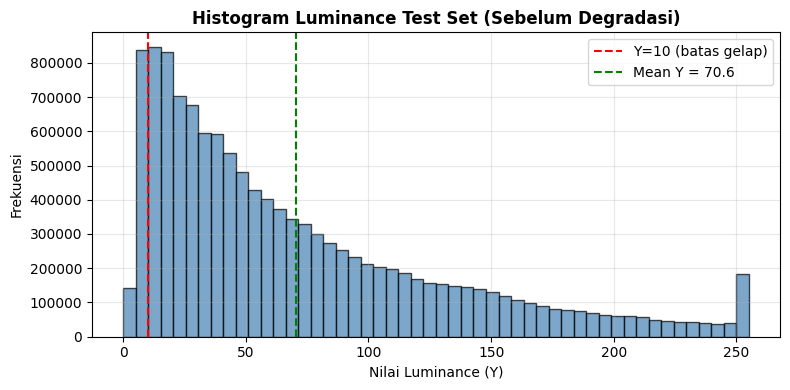

✅ Disimpan ke histogram_sebelum_degradasi.png


In [11]:
# ── 1. CEK GAMBAR TERLALU GELAP (Y <= 10) ────────────────────────
print('='*55)
print('1. CEK GAMBAR TERLALU GELAP (Y <= 10)')
print('='*55)
too_dark = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    if float(Y.mean()) <= 10:
        too_dark.append({'file': fname, 'mean_Y': round(float(Y.mean()), 2)})

if too_dark:
    print(f'⚠️ {len(too_dark)} gambar terlalu gelap (Y <= 10):')
    print(pd.DataFrame(too_dark))
else:
    print('✅ Tidak ada gambar yang terlalu gelap (Y <= 10)')

# ── 2. HITUNG SNRrough ────────────────────────────────────────────
print('\n' + '='*55)
print('2. HITUNG SNRrough = rerata Y / sigma Y')
print('='*55)
snr_log = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    mean_Y  = float(Y.mean())
    std_Y   = float(Y.std())
    snr_rough = mean_Y / std_Y if std_Y != 0 else 0
    snr_log.append({'file': fname, 'mean_Y': round(mean_Y, 2),
                    'std_Y': round(std_Y, 2), 'SNRrough': round(snr_rough, 3)})

df_snr = pd.DataFrame(snr_log)
df_snr.to_csv('snr_rough.csv', index=False)
print(f'SNRrough rata-rata : {df_snr["SNRrough"].mean():.3f}')
print(f'SNRrough minimum   : {df_snr["SNRrough"].min():.3f}')
print(f'SNRrough maksimum  : {df_snr["SNRrough"].max():.3f}')
print('✅ Disimpan ke snr_rough.csv')

# ── 3. HITUNG SNR = Var(Signal) / Var(Noise) ─────────────────────
print('\n' + '='*55)
print('3. HITUNG SNR = Var(Signal) / Var(Noise)')
print('='*55)
snr_full_log = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    signal  = cv2.GaussianBlur(Y.astype(np.uint8), (5,5), 0).astype(float)
    noise   = Y - signal
    var_s   = float(np.var(signal))
    var_n   = float(np.var(noise))
    snr     = var_s / var_n if var_n != 0 else 0
    snr_full_log.append({'file': fname, 'var_signal': round(var_s, 3),
                         'var_noise': round(var_n, 3), 'SNR': round(snr, 3)})

df_snr_full = pd.DataFrame(snr_full_log)
df_snr_full.to_csv('snr_full.csv', index=False)
print(f'SNR rata-rata  : {df_snr_full["SNR"].mean():.3f}')
print(f'SNR minimum    : {df_snr_full["SNR"].min():.3f}')
print(f'SNR maksimum   : {df_snr_full["SNR"].max():.3f}')
print('✅ Disimpan ke snr_full.csv')

# ── 4. HISTOGRAM LUMINANCE ────────────────────────────────────────
print('\n' + '='*55)
print('4. HISTOGRAM LUMINANCE TEST SET (ORIGINAL)')
print('='*55)
all_Y = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    all_Y.extend(Y.flatten().tolist())

plt.figure(figsize=(8, 4))
plt.hist(all_Y, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', label='Y=10 (batas gelap)')
plt.axvline(x=np.mean(all_Y), color='green', linestyle='--',
            label=f'Mean Y = {np.mean(all_Y):.1f}')
plt.title('Histogram Luminance Test Set (Sebelum Degradasi)', fontweight='bold')
plt.xlabel('Nilai Luminance (Y)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('histogram_sebelum_degradasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke histogram_sebelum_degradasi.png')

---
## SEL 9 — Degradasi Test Set & Persiapan Training Beragam

**1. Degradasi Test Set** (54 gambar val)

| Kondisi | Parameter | Keterangan |
|---------|-----------|------------|
| `low_light` | Brightness -35%, Contrast -25% | Cahaya redup lebih gelap |
| `noisy` | Gaussian noise sigma=30 | Noise lebih banyak |
| `blurry` | Gaussian blur kernel 7×7 | Blur lebih kuat |
| `compressed` | JPEG quality=15 | Artefak kompresi lebih parah |
| `combined` | Semua digabung (lebih kuat) | Kondisi terburuk |

**2. Augmentasi Training Model B** (214 gambar train)
- Degradasi yang sama diterapkan ke training set
- Total training B = 214 × 6 = **1284 gambar**

> ⚠️ Degradasi test set dan training B menggunakan parameter **SAMA**
> agar perbandingan adil.
> Training set Model A tetap **asli apa adanya**.

In [12]:
import tempfile

# ══════════════════════════════════════════════════════════
# FUNGSI DEGRADASI (parameter lebih kuat)
# ══════════════════════════════════════════════════════════

def apply_low_light(img_rgb):
    """Brightness -35%, Contrast -25% (lebih gelap dari sebelumnya)"""
    deg    = img_rgb.copy() * 0.65        # brightness -35%
    mean_d = deg.mean(axis=(0,1), keepdims=True)
    deg    = (deg - mean_d) * 0.75 + mean_d  # contrast -25%
    return np.clip(deg, 0, 255)

def apply_noise(img_rgb):
    """Gaussian noise sigma=30 (lebih banyak noise)"""
    noise = np.random.normal(0, 30, img_rgb.shape)
    return np.clip(img_rgb + noise, 0, 255)

def apply_blur(img_rgb):
    """Gaussian blur kernel 7x7 (lebih kuat dari 3x3)"""
    blurred = cv2.GaussianBlur(img_rgb.astype(np.uint8), (7,7), 0)
    return blurred.astype(float)

def apply_compression(img_rgb, quality=15):
    """JPEG quality=15 (artefak lebih parah)"""
    img_bgr = cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
    _, enc  = cv2.imencode('.jpg', img_bgr,
                           [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    dec     = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB).astype(float)

def apply_combined(img_rgb):
    """Gabungan lebih kuat: low_light + noise + blur + kompresi"""
    deg = img_rgb.copy() * 0.65              # low light -35%
    mean_d = deg.mean(axis=(0,1), keepdims=True)
    deg = (deg - mean_d) * 0.75 + mean_d    # contrast -25%
    deg = np.clip(deg, 0, 255)
    noise = np.random.normal(0, 25, deg.shape) # noise sigma=25
    deg = np.clip(deg + noise, 0, 255)
    deg = cv2.GaussianBlur(                  # blur 5x5
        deg.astype(np.uint8), (5,5), 0).astype(float)
    img_bgr = cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR)
    _, enc  = cv2.imencode('.jpg', img_bgr,  # kompresi quality=20
                           [int(cv2.IMWRITE_JPEG_QUALITY), 20])
    dec     = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB).astype(float)

# Daftar semua jenis degradasi
degradations = {
    'low_light'  : apply_low_light,
    'noisy'      : apply_noise,
    'blurry'     : apply_blur,
    'compressed' : apply_compression,
    'combined'   : apply_combined,
}

# ══════════════════════════════════════════════════════════════
# BAGIAN 1: DEGRADASI TEST SET (img_val = 54 gambar)
# ══════════════════════════════════════════════════════════════
print('='*55)
print('BAGIAN 1 — DEGRADASI TEST SET (54 gambar val)')
print('⚠️  Hanya untuk img_val, bukan img_train!')
print('='*55)

for deg_name in degradations:
    os.makedirs(f'{images_path}/{deg_name}', exist_ok=True)

log = []
for fname in os.listdir(img_val):  # ← img_val saja!
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    fpath   = os.path.join(img_val, fname)
    img_bgr = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y_ori     = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    mean_awal = float(Y_ori.mean())
    std_awal  = float(Y_ori.std())

    for deg_name, deg_func in degradations.items():
        deg      = deg_func(img_rgb)
        Y_deg    = 0.299*deg[:,:,0] + 0.587*deg[:,:,1] + 0.114*deg[:,:,2]
        mean_deg = float(Y_deg.mean())
        std_deg  = float(Y_deg.std())
        out_path = f'{images_path}/{deg_name}/{fname}'
        if mean_deg < 0.7*mean_awal or std_deg < 0.6*std_awal:
            shutil.copy(fpath, out_path)
            status = 'SKIP'
        else:
            cv2.imwrite(out_path,
                cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR))
            status = 'OK'
        log.append({'file': fname, 'level': deg_name, 'status': status})

df_log = pd.DataFrame(log)
print(df_log.groupby(['level','status']).size())
print(f'\n✅ Test set terdegradasi selesai!')
print(f'   Folder : {list(degradations.keys())}')
print(f'   Gambar : {len(os.listdir(img_val))} gambar × {len(degradations)} kondisi')
print(f'   ⚠️  img_train TIDAK disentuh sama sekali!')

# ══════════════════════════════════════════════════════════════
# BAGIAN 2: AUGMENTASI TRAINING MODEL B (img_train = 214 gambar)
# ══════════════════════════════════════════════════════════════
print('\n' + '='*55)
print('BAGIAN 2 — AUGMENTASI TRAINING MODEL B (214 gambar train)')
print('⚠️  Hanya untuk img_train, bukan img_val!')
print('='*55)

img_train_aug = f'{images_path}/train_augmented'
lbl_train_aug = f'{labels_path}/train_augmented'
os.makedirs(img_train_aug, exist_ok=True)
os.makedirs(lbl_train_aug, exist_ok=True)

# Step 1: Copy data normal dulu
count_normal = 0
for fname in os.listdir(img_train):  # ← img_train saja!
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    name    = os.path.splitext(fname)[0]
    shutil.copy(os.path.join(img_train, fname),
                os.path.join(img_train_aug, fname))
    src_lbl = os.path.join(lbl_train, name + '.txt')
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, os.path.join(lbl_train_aug, name + '.txt'))
    count_normal += 1

print(f'Data normal disalin : {count_normal} gambar')

# Step 2: Tambahkan versi terdegradasi
count_aug = 0
for fname in os.listdir(img_train):  # ← img_train saja!
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    name    = os.path.splitext(fname)[0]
    fpath   = os.path.join(img_train, fname)
    src_lbl = os.path.join(lbl_train, name + '.txt')
    img_bgr = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)

    for deg_name, deg_func in degradations.items():
        new_name  = f'{name}_{deg_name}'
        out_img   = os.path.join(img_train_aug, f'{new_name}.jpg')
        out_lbl   = os.path.join(lbl_train_aug, f'{new_name}.txt')
        deg       = deg_func(img_rgb)
        cv2.imwrite(out_img,
            cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR))
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, out_lbl)
        count_aug += 1

total = len([f for f in os.listdir(img_train_aug)
             if f.endswith(('.jpg','.jpeg','.png'))])
print(f'Data terdegradasi ditambah: {count_aug} gambar')
print(f'Total training Model B    : {total} gambar')
print(f'\n✅ Selesai!')
print(f'   img_val TIDAK disentuh sama sekali!')
print(f'\nRingkasan:')
print(f'   Model A training → img_train     ({count_normal} gambar normal)')
print(f'   Model B training → img_train_aug ({total} gambar normal+terdegradasi)')
print(f'   Test set         → img_val + 5 kondisi degradasi')


BAGIAN 1 — DEGRADASI TEST SET (54 gambar val)
⚠️  Hanya untuk img_val, bukan img_train!
level       status
blurry      OK        54
combined    SKIP      54
compressed  OK        54
low_light   SKIP      54
noisy       OK        54
dtype: int64

✅ Test set terdegradasi selesai!
   Folder : ['low_light', 'noisy', 'blurry', 'compressed', 'combined']
   Gambar : 54 gambar × 5 kondisi
   ⚠️  img_train TIDAK disentuh sama sekali!

BAGIAN 2 — AUGMENTASI TRAINING MODEL B (214 gambar train)
⚠️  Hanya untuk img_train, bukan img_val!
Data normal disalin : 214 gambar
Data terdegradasi ditambah: 1070 gambar
Total training Model B    : 1284 gambar

✅ Selesai!
   img_val TIDAK disentuh sama sekali!

Ringkasan:
   Model A training → img_train     (214 gambar normal)
   Model B training → img_train_aug (1284 gambar normal+terdegradasi)
   Test set         → img_val + 5 kondisi degradasi


---
## SEL 9b — Histogram Perbandingan Setelah Degradasi
Memvisualisasikan distribusi luminance pada ketiga kondisi test set
untuk memastikan degradasi bermakna dan tidak berlebihan.

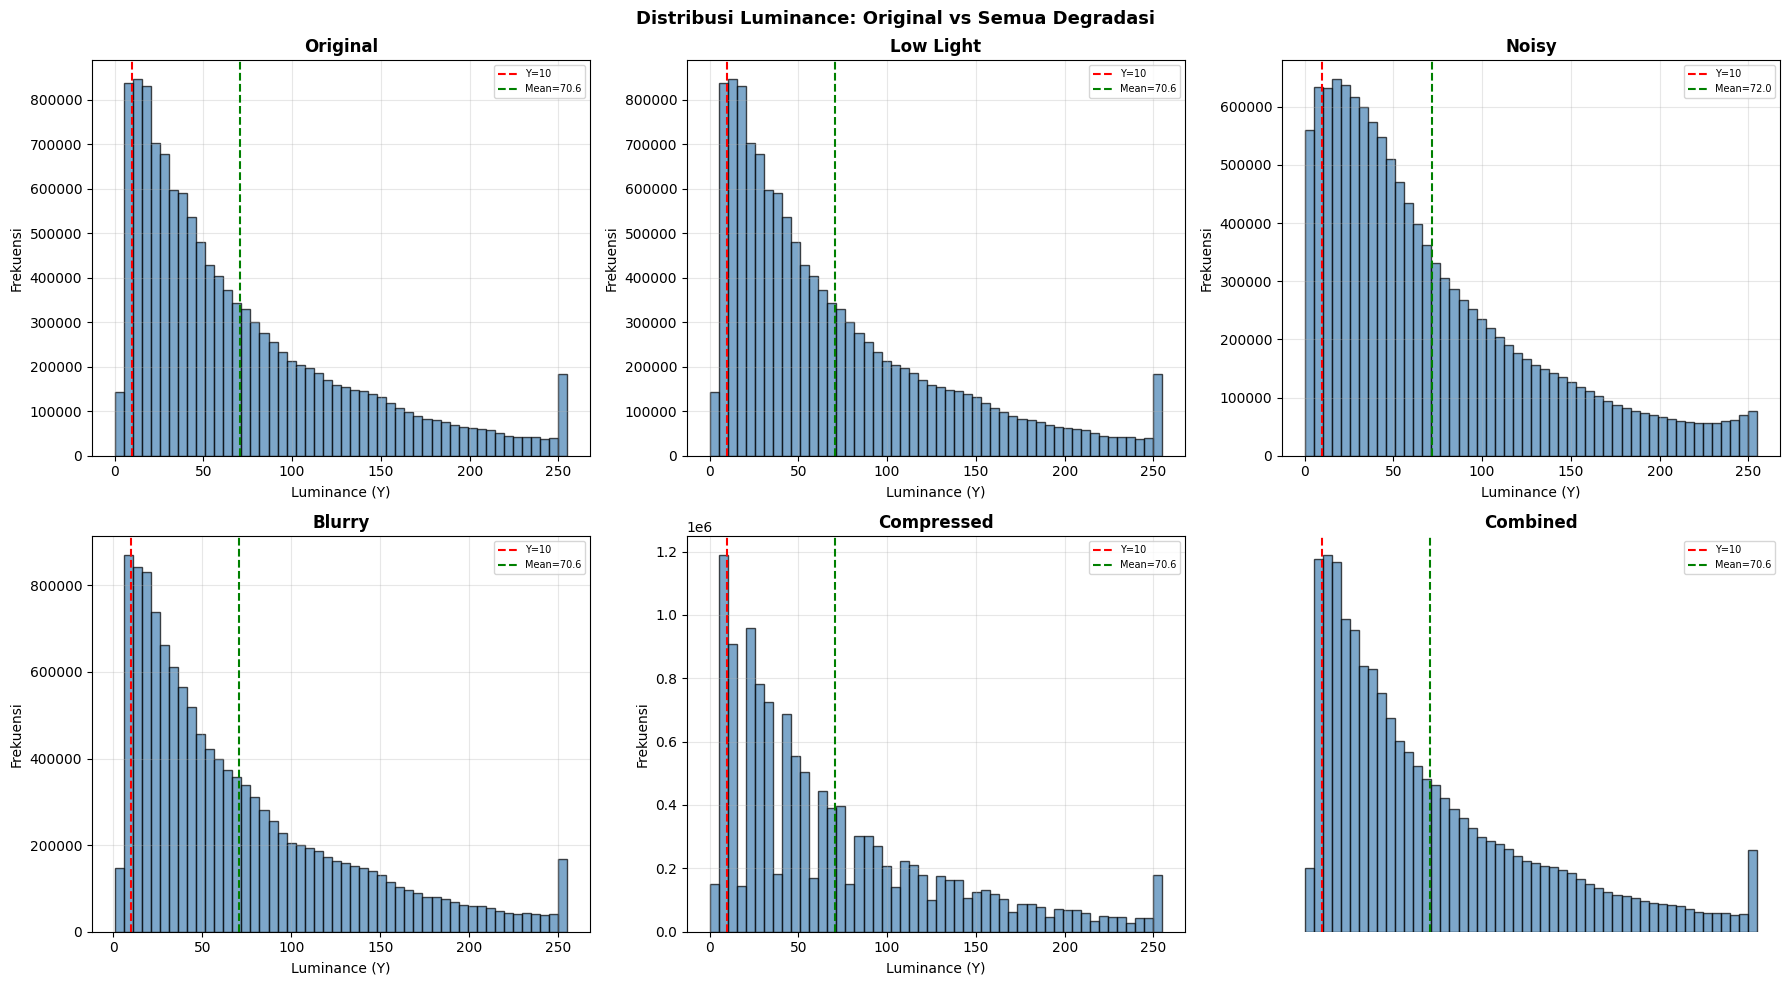

✅ Disimpan ke histogram_luminance.png


In [13]:
test_conditions = {
    'Original'   : img_val,
    'Low Light'  : f'{images_path}/low_light',
    'Noisy'      : f'{images_path}/noisy',
    'Blurry'     : f'{images_path}/blurry',
    'Compressed' : f'{images_path}/compressed',
    'Combined'   : f'{images_path}/combined',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, (ax, (condition, path)) in enumerate(zip(axes, test_conditions.items())):
    all_Y = []
    for fname in os.listdir(path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_bgr = cv2.imread(os.path.join(path, fname))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
        Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
        all_Y.extend(Y.flatten().tolist())
    ax.hist(all_Y, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=10, color='red', linestyle='--', label='Y=10')
    ax.axvline(x=np.mean(all_Y), color='green', linestyle='--',
               label=f'Mean={np.mean(all_Y):.1f}')
    ax.set_title(f'{condition}', fontweight='bold')
    ax.set_xlabel('Luminance (Y)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Sembunyikan subplot ke-6 yang kosong
axes[5].axis('off')

plt.suptitle('Distribusi Luminance: Original vs Semua Degradasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_luminance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke histogram_luminance.png')


---
## SEL 10 — Buat data.yaml
Membuat **2 file yaml** untuk 2 model yang berbeda:
- `data.yaml` → Model A (training normal saja)
- `data_augmented.yaml` → Model B (training normal + terdegradasi)

In [14]:
import yaml

# data.yaml → Model A (dataset normal saja)
data_yaml = {
    'path' : base,
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : 1,
    'names': ['corrosion']
}
with open(f'{base}/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

# data_augmented.yaml → Model B (normal + terdegradasi)
data_yaml_aug = {
    'path' : base,
    'train': 'images/train_augmented',
    'val'  : 'images/val',
    'nc'   : 1,
    'names': ['corrosion']
}
with open(f'{base}/data_augmented.yaml', 'w') as f:
    yaml.dump(data_yaml_aug, f)

print('✅ File yaml berhasil dibuat!')
print(f'   data.yaml          → training normal ({len(os.listdir(img_train))} gambar)')
print(f'   data_augmented.yaml → training normal + terdegradasi')


✅ File yaml berhasil dibuat!
   data.yaml          → training normal (214 gambar)
   data_augmented.yaml → training normal + terdegradasi


---
## SEL 11 — Training YOLOv12
Melatih model YOLOv12 menggunakan **dataset asli apa adanya**.

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| Model | yolov12n | Versi nano, attention-centric |
| Epochs | 50 | Jumlah iterasi training |
| Batch | 16 | Jumlah gambar per batch |
| Imgsz | 640 | Ukuran gambar input |

**Keunggulan YOLOv12 vs YOLOv8:**
- Menggunakan Area Attention mechanism (bukan CNN biasa)
- mAP lebih tinggi dengan kecepatan kompetitif
- FlashAttention untuk efisiensi memori di GPU A100

Model terbaik disimpan otomatis sebagai `best.pt`.

In [15]:
# ── MODEL A: Training dengan data NORMAL ─────────────────────
print('='*50)
print('Training yolo_A — Data Normal...')
print('='*50)
model_yolo_A = YOLO('yolov12n.pt')
model_yolo_A.train(
    data     = f'{base}/data.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'yolo_A',
    project  = '/content/runs/yolo',
    exist_ok = True,
)
print('✅ yolo_A selesai!')
print('   Model : /content/runs/yolo/yolo_A/weights/best.pt')

# ── MODEL B: Training dengan data NORMAL + TERDEGRADASI ───────
print('\n' + '='*50)
print('Training yolo_B — Data Normal + Terdegradasi...')
print('='*50)
model_yolo_B = YOLO('yolov12n.pt')
model_yolo_B.train(
    data     = f'{base}/data_augmented.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'yolo_B',
    project  = '/content/runs/yolo',
    exist_ok = True,
)
print('✅ yolo_B selesai!')
print('   Model : /content/runs/yolo/yolo_B/weights/best.pt')
print('\n✅ Semua model YOLOv12 selesai ditraining!')


Training yolo_A — Data Normal...


100%|██████████| 5.26M/5.26M [00:00<00:00, 368MB/s]

New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.pt, data=/content/datasets/corrosion detect/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/runs/yolo, name=yolo_A, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_ma

100%|██████████| 755k/755k [00:00<00:00, 128MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2, 1, 4]          
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    174720  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

...

      50/50      3.78G     0.9133       0.51     0.9808         72        640: 100%|██████████| 80/80 [00:12<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  7.75it/s]

                   all         52        419      0.454      0.396      0.357      0.127



50 epochs completed in 0.200 hours.
Optimizer stripped from /content/runs/yolo/yolo_B/weights/last.pt, 5.4MB
Optimizer stripped from /content/runs/yolo/yolo_B/weights/best.pt, 5.4MB

Validating /content/runs/yolo/yolo_B/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv12n summary (fused): 376 layers, 2,508,539 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  6.04it/s]


                   all         52        419      0.515      0.365      0.371      0.129
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/yolo/yolo_B
✅ yolo_B selesai!
   Model : /content/runs/yolo/yolo_B/weights/best.pt

✅ Semua model YOLOv12 selesai ditraining!


---
## SEL 12 — Evaluasi YOLOv12 pada Test Set
Menguji model yolo_A (YOLOv12n) pada 6 kondisi test set:
- `original` → gambar asli
- `low_light` → cahaya redup
- `noisy` → ada noise
- `blurry` → gambar blur
- `compressed` → kompresi JPEG rendah
- `combined` → semua digabung

Indikator yang dihitung per gambar:
- **n_instance** : jumlah bounding box korosi terdeteksi
- **area_ratio** : total luas kotak ÷ luas gambar
- **box_density** : jumlah kotak per 1 juta piksel

In [1]:
test_sets = {
    'original'   : img_val,
    'low_light'  : f'{images_path}/low_light',
    'noisy'      : f'{images_path}/noisy',
    'blurry'     : f'{images_path}/blurry',
    'compressed' : f'{images_path}/compressed',
    'combined'   : f'{images_path}/combined',
}

results_log_yolo = []

# Evaluasi kedua model YOLO
yolo_models = {
    'yolo_A': YOLO('/content/runs/yolo/yolo_A/weights/best.pt'),
    'yolo_B': YOLO('/content/runs/yolo/yolo_B/weights/best.pt'),
}

for model_name, model in yolo_models.items():
    for test_name, test_path in test_sets.items():
        print(f'Evaluasi {model_name} pada {test_name}...')
        for fname in os.listdir(test_path):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                continue
            img_path     = os.path.join(test_path, fname)
            img_bgr      = cv2.imread(img_path)
            img_h, img_w = img_bgr.shape[:2]
            results      = model(img_path, verbose=False)
            boxes        = results[0].boxes
            n_instance   = len(boxes)
            if n_instance > 0:
                areas = []
                for box in boxes.xyxy.cpu().numpy():
                    x1, y1, x2, y2 = box
                    areas.append(((x2-x1)/img_w) * ((y2-y1)/img_h))
                area_ratio  = sum(areas)
                box_density = n_instance / (img_w * img_h) * 1e6
            else:
                area_ratio  = 0.0
                box_density = 0.0
            results_log_yolo.append({
                'model'      : model_name,
                'test_set'   : test_name,
                'file'       : fname,
                'n_instance' : n_instance,
                'area_ratio' : round(area_ratio, 4),
                'box_density': round(box_density, 4),
            })

df_yolo = pd.DataFrame(results_log_yolo)
df_yolo.to_csv('eval_results_yolo.csv', index=False)
print('\n✅ Evaluasi YOLO selesai!')
print(df_yolo.groupby(['model','test_set'])['n_instance'].mean().round(2))


NameError: name 'img_val' is not defined

---
## SEL 13 — Hitung Stabilitas YOLO
Mengukur seberapa stabil indikator kerusakan ketika kualitas citra menurun.

| Metrik | Formula | Interpretasi |
|--------|---------|---------------|
| CV (%) | std/mean × 100% | Makin kecil = makin stabil |
| Relative Change (%) | (mod-ori)/ori × 100% | Makin kecil = makin stabil |
| Spearman Trend | korelasi(level, nilai) | -1.0 = turun konsisten |

In [18]:
df_yolo = pd.read_csv('eval_results_yolo.csv')
metrics_cols = ['n_instance', 'area_ratio', 'box_density']
stability_log = []
test_order = ['original', 'low_light', 'noisy',
              'blurry', 'compressed', 'combined']

for model_name in ['yolo_A', 'yolo_B']:
    df_m = df_yolo[df_yolo['model'] == model_name]
    for metric in metrics_cols:
        means = {ts: df_m[df_m['test_set']==ts][metric].mean() for ts in test_order}
        vals  = [means[ts] for ts in test_order]
        cv    = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0
        rel_change = ((means['combined'] - means['original']) / means['original'] * 100) \
                      if means['original'] != 0 else 0
        spearman_r, spearman_p = stats.spearmanr([0,1,2,3,4,5], vals)
        stability_log.append({
            'model'          : model_name,
            'metric'         : metric,
            'mean_ori'       : round(means['original'],   4),
            'mean_lowlight'  : round(means['low_light'],  4),
            'mean_noisy'     : round(means['noisy'],      4),
            'mean_blurry'    : round(means['blurry'],     4),
            'mean_compressed': round(means['compressed'], 4),
            'mean_combined'  : round(means['combined'],   4),
            'CV(%)'          : round(cv, 2),
            'rel_change(%)'  : round(rel_change, 2),
            'spearman_r'     : round(spearman_r, 3),
            'spearman_p'     : round(spearman_p, 3)
        })

df_stab_yolo = pd.DataFrame(stability_log)
df_stab_yolo.to_csv('stability_results_yolo.csv', index=False)
print(df_stab_yolo[['model','metric','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))
print('\n✅ Disimpan ke stability_results_yolo.csv')

 model      metric  CV(%)  rel_change(%)  spearman_r
yolo_A  n_instance  43.90            0.0      -0.152
yolo_A  area_ratio  46.36            0.0      -0.030
yolo_A box_density  44.69            0.0      -0.152
yolo_B  n_instance   7.20            0.0      -0.213
yolo_B  area_ratio   8.79            0.0      -0.213
yolo_B box_density   7.14            0.0      -0.213

✅ Disimpan ke stability_results_yolo.csv


In [15]:
metrics_cols = ['n_instance', 'area_ratio', 'box_density']
test_order   = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']
stability_log = []

df_yolo = pd.read_csv('eval_results_yolo.csv')

for metric in metrics_cols:
    means = {ts: df_yolo[df_yolo['test_set']==ts][metric].mean() for ts in test_order}
    vals  = [means[ts] for ts in test_order]
    cv    = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0
    # Relative change dari original ke combined (kondisi terburuk)
    rel_change = ((means['combined'] - means['original']) / means['original'] * 100) \
                  if means['original'] != 0 else 0
    deg_levels = [0, 1, 2, 3, 4, 5]
    spearman_r, spearman_p = stats.spearmanr(deg_levels, vals)
    stability_log.append({
        'model'        : 'yolo_A',
        'metric'       : metric,
        'mean_ori'     : round(means['original'], 4),
        'mean_lowlight': round(means['low_light'], 4),
        'mean_noisy'   : round(means['noisy'], 4),
        'mean_blurry'  : round(means['blurry'], 4),
        'mean_compressed': round(means['compressed'], 4),
    'mean_combined': round(means['combined'], 4),
        'CV(%)'        : round(cv, 2),
        'rel_change(%)': round(rel_change, 2),
        'spearman_r'   : round(spearman_r, 3),
        'spearman_p'   : round(spearman_p, 3),
    })

df_stab_yolo = pd.DataFrame(stability_log)
df_stab_yolo.to_csv('stability_results_yolo.csv', index=False)

print('='*60)
print('HASIL STABILITAS YOLOv12')
print('='*60)
print(df_stab_yolo[['metric','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))
print('\n✅ Disimpan ke stability_results_yolo.csv')

HASIL STABILITAS YOLOv12
     metric  CV(%)  rel_change(%)  spearman_r
 n_instance  20.02            0.0      -0.152
 area_ratio  13.95            0.0      -0.213
box_density  21.77            0.0      -0.152

✅ Disimpan ke stability_results_yolo.csv


---
## SEL 14 — Ranking Stability YOLO
Mengukur apakah **urutan ranking** gambar berdasarkan tingkat korosi
tetap konsisten meskipun kualitas citra menurun.

Model dinyatakan **rank-stable** jika Spearman > 0.7

In [21]:
df_yolo = pd.read_csv('eval_results_yolo.csv')
ranking_log = []
test_order = ['original', 'low_light', 'noisy',
              'blurry', 'compressed', 'combined']

for model_name in ['yolo_A', 'yolo_B']:
    df_m = df_yolo[df_yolo['model'] == model_name]
    for metric in metrics_cols:
        ranks = {}
        for ts in test_order:
            vals = df_m[df_m['test_set']==ts].set_index('file')[metric]
            ranks[ts] = vals.rank(ascending=False)
        common = set(ranks['original'].index)
        for ts in test_order[1:]:
            common &= set(ranks[ts].index)
        common = list(common)
        r_ll, _ = stats.spearmanr(ranks['original'][common],
                                  ranks['low_light'][common])
        r_no, _ = stats.spearmanr(ranks['original'][common],
                                  ranks['noisy'][common])
        r_bl, _ = stats.spearmanr(ranks['original'][common],
                                  ranks['blurry'][common])
        r_cp, _ = stats.spearmanr(ranks['original'][common],
                                  ranks['compressed'][common])
        r_co, _ = stats.spearmanr(ranks['original'][common],
                                  ranks['combined'][common])
        ranking_log.append({
            'model'              : model_name,
            'metric'             : metric,
            'spearman_low_light' : round(r_ll, 3),
            'spearman_noisy'     : round(r_no, 3),
            'spearman_blurry'    : round(r_bl, 3),
            'spearman_compressed': round(r_cp, 3),
            'spearman_combined'  : round(r_co, 3),
            'rank_stable'        : 'YA' if r_co > 0.7 else 'TIDAK'
        })

df_rank_yolo = pd.DataFrame(ranking_log)
df_rank_yolo.to_csv('ranking_stability_yolo.csv', index=False)
print(df_rank_yolo.to_string(index=False))
print('\n✅ Disimpan ke ranking_stability_yolo.csv')

 model      metric  spearman_low_light  spearman_noisy  spearman_blurry  spearman_compressed  spearman_combined rank_stable
yolo_A  n_instance                 1.0           0.449            0.903                0.688                1.0          YA
yolo_A  area_ratio                 1.0           0.413            0.907                0.844                1.0          YA
yolo_A box_density                 1.0           0.455            0.898                0.765                1.0          YA
yolo_B  n_instance                 1.0           0.898            0.971                0.921                1.0          YA
yolo_B  area_ratio                 1.0           0.910            0.939                0.911                1.0          YA
yolo_B box_density                 1.0           0.914            0.972                0.936                1.0          YA

✅ Disimpan ke ranking_stability_yolo.csv


In [16]:
df_yolo     = pd.read_csv('eval_results_yolo.csv')
ranking_log = []
test_order  = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    ranks = {}
    for ts in test_order:
        vals      = df_yolo[df_yolo['test_set']==ts].set_index('file')[metric]
        ranks[ts] = vals.rank(ascending=False)
    # Cari file yang sama di semua kondisi
    common = set(ranks['original'].index)
    for ts in test_order[1:]:
        common &= set(ranks[ts].index)
    common = list(common)
    # Hitung spearman untuk setiap kondisi vs original
    r_ll, _ = stats.spearmanr(ranks['original'][common], ranks['low_light'][common])
    r_no, _ = stats.spearmanr(ranks['original'][common], ranks['noisy'][common])
    r_bl, _ = stats.spearmanr(ranks['original'][common], ranks['blurry'][common])
    r_cp, _ = stats.spearmanr(ranks['original'][common], ranks['compressed'][common])
    r_co, _ = stats.spearmanr(ranks['original'][common], ranks['combined'][common])
    ranking_log.append({
        'model'               : 'yolo_A',
        'metric'              : metric,
        'spearman_low_light'  : round(r_ll, 3),
        'spearman_noisy'      : round(r_no, 3),
        'spearman_blurry'     : round(r_bl, 3),
        'spearman_compressed' : round(r_cp, 3),
        'spearman_combined'   : round(r_co, 3),
        'rank_stable'         : 'YA' if r_co > 0.7 else 'TIDAK'
    })

df_rank_yolo = pd.DataFrame(ranking_log)
df_rank_yolo.to_csv('ranking_stability_yolo.csv', index=False)

print('='*60)
print('RANKING STABILITY YOLOv12')
print('='*60)
print(df_rank_yolo.to_string(index=False))
print('\n✅ Disimpan ke ranking_stability_yolo.csv')

RANKING STABILITY YOLOv12
 model      metric  spearman_low_light  spearman_noisy  spearman_blurry  spearman_compressed  spearman_combined rank_stable
yolo_A  n_instance                 1.0           0.556            0.917                0.858                1.0          YA
yolo_A  area_ratio                 1.0           0.622            0.950                0.894                1.0          YA
yolo_A box_density                 1.0           0.554            0.929                0.886                1.0          YA

✅ Disimpan ke ranking_stability_yolo.csv


---
## SEL 15 — Rekap Hasil YOLO
Menggabungkan semua hasil evaluasi dan stabilitas YOLOv8 dalam satu tabel.

In [23]:
df_s = pd.read_csv('stability_results_yolo.csv')
df_r = pd.read_csv('ranking_stability_yolo.csv')

rows = []
for model_name in ['yolo_A', 'yolo_B']:
    for metric in metrics_cols:
        s = df_s[(df_s['model']==model_name) &
(df_s['metric']==metric)].iloc[0]
        r = df_r[(df_r['model']==model_name) &
(df_r['metric']==metric)].iloc[0]
        rows.append({
            'Model'            : model_name,
            'Metrik'           : metric,
            'Mean_Ori'         : s['mean_ori'],
            'Mean_Combined'    : s['mean_combined'],
            'CV_pct'           : s['CV(%)'],
            'RelChange_pct'    : s['rel_change(%)'],
            'Spearman_trend'   : s['spearman_r'],
            'Spearman_Combined':
r['spearman_combined'],
            'Rank_Stabil'      : r['rank_stable'],
        })

df_rekap_yolo = pd.DataFrame(rows)
df_rekap_yolo.to_csv('rekap_yolo.csv', index=False)
print('REKAP HASIL YOLOv12')
print('='*70)
print(df_rekap_yolo.to_string(index=False))
print('\n✅ Disimpan ke rekap_yolo.csv')

REKAP HASIL YOLOv12
 Model      Metrik  Mean_Ori  Mean_Combined  CV_pct  RelChange_pct  Spearman_trend  Spearman_Combined Rank_Stabil
yolo_A  n_instance    8.1481         8.1481   43.90            0.0          -0.152                1.0          YA
yolo_A  area_ratio    0.1850         0.1850   46.36            0.0          -0.030                1.0          YA
yolo_A box_density   44.2189        44.2189   44.69            0.0          -0.152                1.0          YA
yolo_B  n_instance    7.6852         7.6852    7.20            0.0          -0.213                1.0          YA
yolo_B  area_ratio    0.1995         0.1995    8.79            0.0          -0.213                1.0          YA
yolo_B box_density   41.3739        41.3739    7.14            0.0          -0.213                1.0          YA

✅ Disimpan ke rekap_yolo.csv


In [18]:
df_s = pd.read_csv('stability_results_yolo.csv')
df_r = pd.read_csv('ranking_stability_yolo.csv')

rows = []
for model_name in df_s['model'].unique():
    for metric in metrics_cols:
        s = df_s[(df_s['model']==model_name) & (df_s['metric']==metric)].iloc[0]
        r = df_r[(df_r['model']==model_name) & (df_r['metric']==metric)].iloc[0]
        rows.append({
            'Model'             : model_name,
            'Metrik'            : metric,
            'Mean_Ori'          : s['mean_ori'],
            'Mean_Combined'     : s['mean_combined'],
            'CV_pct'            : s['CV(%)'],
            'RelChange_pct'     : s['rel_change(%)'],
            'Spearman_trend'    : s['spearman_r'],
            'Spearman_Ori_Comb' : r['spearman_combined'],
            'Rank_Stabil'       : r['rank_stable'],
        })

df_rekap_yolo = pd.DataFrame(rows)
df_rekap_yolo.to_csv('rekap_yolo.csv', index=False)
print('REKAP HASIL YOLOv12')
print('='*70)
print(df_rekap_yolo.to_string(index=False))
print('\n✅ Disimpan ke rekap_yolo.csv')

REKAP HASIL YOLOv12
 Model      Metrik  Mean_Ori  Mean_Combined  CV_pct  RelChange_pct  Spearman_trend  Spearman_Ori_Comb Rank_Stabil
yolo_A  n_instance    6.6759         6.6759   20.02            0.0          -0.152                1.0          YA
yolo_A  area_ratio    0.1581         0.1581   13.95            0.0          -0.213                1.0          YA
yolo_A box_density   36.9846        36.9846   21.77            0.0          -0.152                1.0          YA

✅ Disimpan ke rekap_yolo.csv


---
## SEL 16 — Konversi YOLO ke Format COCO
Faster R-CNN (Detectron2) membutuhkan format anotasi **COCO (.json)**,
berbeda dengan YOLOv8 yang menggunakan format **.txt**.

Konversi dilakukan dari koordinat relatif (YOLO) ke koordinat piksel absolut (COCO).

In [24]:
def yolo_to_coco(images_dir, labels_dir, output_json):
    images, annotations, ann_id = [], [], 1
    for img_id, fname in enumerate(sorted(
        [f for f in os.listdir(images_dir)
         if f.endswith(('.jpg','.jpeg','.png'))]), 1):
        img   = cv2.imread(os.path.join(images_dir, fname))
        h, w  = img.shape[:2]
        images.append({'id': img_id, 'file_name': fname, 'height': h, 'width': w})
        label_file = os.path.join(labels_dir, os.path.splitext(fname)[0] + '.txt')
        if not os.path.exists(label_file):
            continue
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1, y1 = (cx - bw/2) * w, (cy - bh/2) * h
                bw_px, bh_px = bw * w, bh * h
                annotations.append({
                    'id': ann_id, 'image_id': img_id, 'category_id': 1,
                    'bbox': [x1, y1, bw_px, bh_px],
                    'area': bw_px * bh_px, 'iscrowd': 0
                })
                ann_id += 1
    coco = {'images': images, 'annotations': annotations,
            'categories': [{'id': 1, 'name': 'corrosion'}]}
    with open(output_json, 'w') as f:
        json.dump(coco, f)
    print(f'✅ {os.path.basename(output_json)} → {len(images)} gambar, {len(annotations)} anotasi')

# Model A → data normal
yolo_to_coco(img_train,     lbl_train,     f'{base}/train.json')
# Model B → data normal + terdegradasi
yolo_to_coco(img_train_aug, lbl_train_aug, f'{base}/train_augmented.json')
# Validasi
yolo_to_coco(img_val,       lbl_val,       f'{base}/val.json')
print('\n✅ Semua konversi selesai!')


✅ train.json → 214 gambar, 1671 anotasi
✅ train_augmented.json → 1284 gambar, 10026 anotasi
✅ val.json → 54 gambar, 461 anotasi

✅ Semua konversi selesai!


---
## SEL 17 — Register Dataset ke Torchvision
Mendaftarkan dataset ke katalog internal Detectron2
sebelum dapat digunakan untuk training.

In [25]:
# Path dataset untuk Faster R-CNN (torchvision)
train_json_A = f'{base}/train.json'
train_json_B = f'{base}/train_augmented.json'
val_json     = f'{base}/val.json'
train_img_A  = img_train
train_img_B  = img_train_aug

print('✅ Path dataset siap!')
print(f'   Model A → {train_json_A}')
print(f'   Model B → {train_json_B}')

✅ Dataset berhasil didaftarkan!
   corrosion_train     → Model A (normal)
   corrosion_train_aug → Model B (normal + terdegradasi)


---
## SEL 18 — Training Faster R-CNN
Melatih model Faster R-CNN menggunakan **dataset asli apa adanya**.

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| Backbone | ResNet-50 FPN | Pretrained COCO |
| Iterasi | 3000 | Jumlah iterasi training |
| Learning Rate | 0.002 | Laju pembelajaran |
| Warmup | 500 iter | Pemanasan learning rate |

Model disimpan sebagai `model_final.pth` pada iterasi terakhir.

In [ ]:
  from torchvision.models.detection import
  fasterrcnn_resnet50_fpn
  from torchvision.models.detection.faster_rcnn import
  FastRCNNPredictor
  from torchvision.ops import MultiScaleRoIAlign
  from torch.utils.data import Dataset, DataLoader

  class CorrosionDataset(Dataset):
      def __init__(self, img_dir, ann_file):
          with open(ann_file) as f:
              coco = json.load(f)
          self.img_dir = img_dir
          self.imgs    = {img['id']: img for img in
  coco['images']}
          self.ann_by_img = {}
          for ann in coco['annotations']:
              img_id = ann['image_id']
              if img_id not in self.ann_by_img:
                  self.ann_by_img[img_id] = []
              self.ann_by_img[img_id].append(ann)
          self.img_ids = list(self.imgs.keys())

      def __len__(self):
          return len(self.img_ids)

      def __getitem__(self, idx):
          img_id   = self.img_ids[idx]
          img_info = self.imgs[img_id]
          img_bgr  =
  cv2.imread(os.path.join(self.img_dir,
  img_info['file_name']))
          img_rgb  = cv2.cvtColor(img_bgr,
  cv2.COLOR_BGR2RGB)
          img_t    =
  torch.from_numpy(img_rgb).permute(2,0,1).float() /
  255.0
          anns     = self.ann_by_img.get(img_id, [])
          boxes    = []
          for ann in anns:
              x, y, w, h = ann['bbox']
              if w > 0 and h > 0:
                  boxes.append([x, y, x+w, y+h])
          if boxes:
              boxes_t  = torch.tensor(boxes,
  dtype=torch.float32)
              labels_t = torch.ones(len(boxes),
  dtype=torch.int64)
          else:
              boxes_t  = torch.zeros((0,4),
  dtype=torch.float32)
              labels_t = torch.zeros(0,
  dtype=torch.int64)
          return img_t, {'boxes': boxes_t, 'labels':
  labels_t,
                         'image_id':
  torch.tensor([img_id])}

  def build_model():
      box_roi_pool = MultiScaleRoIAlign(
          featmap_names=['0','1','2','3'],
          output_size=7,
          sampling_ratio=2  # Fix OOM
      )
      model = fasterrcnn_resnet50_fpn(weights='COCO_V1',

  box_roi_pool=box_roi_pool)
      in_feat =
  model.roi_heads.box_predictor.cls_score.in_features
      model.roi_heads.box_predictor =
  FastRCNNPredictor(in_feat, 2)
      return model

  def collate_fn(batch):
      return tuple(zip(*batch))

  def train_rcnn(train_json, train_img_dir, output_dir,
  num_iter=3000):
      device  = torch.device('cuda' if
  torch.cuda.is_available() else 'cpu')
      print(f'Device: {device}')
      dataset = CorrosionDataset(train_img_dir,
  train_json)
      loader  = DataLoader(dataset, batch_size=2,
  shuffle=True,
                           num_workers=2,
  collate_fn=collate_fn)
      model   = build_model().to(device)
      model.train()
      optimizer = torch.optim.SGD(model.parameters(),
  lr=0.002,
                                   momentum=0.9,
  weight_decay=0.0001)
      scheduler = torch.optim.lr_scheduler.MultiStepLR(
          optimizer, milestones=[2000, 2500], gamma=0.1)
      os.makedirs(output_dir, exist_ok=True)
      iteration = 0
      while iteration < num_iter:
          for imgs, targets in loader:
              if iteration >= num_iter:
                  break
              imgs    = [img.to(device) for img in imgs]
              targets = [{k: v.to(device) for k, v in
  t.items()} for t in targets]
              losses  = sum(loss for loss in model(imgs,
   targets).values())
              optimizer.zero_grad()
              losses.backward()
              optimizer.step()
              scheduler.step()
              iteration += 1
              if iteration % 100 == 0:
                  print(f'  iter {iteration}/{num_iter}
   loss: {losses.item():.4f}')
      torch.save(model.state_dict(),
  f'{output_dir}/model_final.pth')
      print(f'✅ {output_dir} selesai!')
      return model

  # MODEL A
  print('='*50)
  print('Training rcnn_A — Data Normal...')
  print('='*50)
  model_rcnn_A = train_rcnn(train_json_A, train_img_A,

  '/content/runs/rcnn/rcnn_A')
  print('✅ rcnn_A selesai!')

  # MODEL B
  print('\n'+'='*50)
  print('Training rcnn_B — Data Normal +
  Terdegradasi...')
  print('='*50)
  model_rcnn_B = train_rcnn(train_json_B, train_img_B,

  '/content/runs/rcnn/rcnn_B')
  print('✅ rcnn_B selesai!')
  print('\n✅ Semua model Faster R-CNN selesai
  ditraining!')


---
## SEL 19 — Cek Metrics Training RCNN
Memverifikasi hasil training Faster R-CNN:
- `total_loss` → makin kecil makin baik
- `fg_cls_accuracy` → akurasi klasifikasi, target > 80%

In [ ]:
print('HASIL TRAINING FASTER R-CNN')
  print('='*50)
  for model_name in ['rcnn_A', 'rcnn_B']:
      path  =
  f'/content/runs/rcnn/{model_name}/model_final.pth'
      label = 'Data Normal' if model_name == 'rcnn_A'
  else 'Data Normal + Terdegradasi'
      if os.path.exists(path):
          size_mb = os.path.getsize(path) / 1024**2
          print(f'\n{model_name} ({label}):')
          print(f'  Model tersimpan : {path}')
          print(f'  Ukuran file     : {size_mb:.1f} MB')
          print(f'  Status          : ✅')
      else:
          print(f'\n{model_name}: ❌ model_final.pth
  tidak ditemukan')

---
## SEL 20 — Fungsi Visualisasi & Load Predictor RCNN
Mendefinisikan fungsi untuk:
- `get_predictor` : memuat model RCNN dari `model_final.pth`
- `visualize_rcnn` : menampilkan hasil deteksi (bounding box merah)
- `compare_yolo_rcnn` : membandingkan YOLOv12 (biru) vs RCNN (merah)

In [ ]:
def get_predictor(weights_path, threshold=0.3):
      device = torch.device('cuda' if
  torch.cuda.is_available() else 'cpu')
      model  = build_model()
      model.load_state_dict(torch.load(weights_path,
  map_location=device))
      model.eval().to(device)
      return model

  def predict_rcnn(model, img_bgr, threshold=0.3):
      device  = next(model.parameters()).device
      img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
      img_t   =
  torch.from_numpy(img_rgb).permute(2,0,1).float() /
  255.0
      with torch.no_grad():
          out = model([img_t.to(device)])
      boxes  = out[0]['boxes'].cpu().numpy()
      scores = out[0]['scores'].cpu().numpy()
      mask   = scores >= threshold
      return boxes[mask], scores[mask]

  def visualize_rcnn(model, images_dir, title, n=8):
      files = random.sample(
          [f for f in os.listdir(images_dir) if
  f.endswith(('.jpg','.jpeg','.png'))],
          min(n, len(os.listdir(images_dir))))
      fig, axes = plt.subplots(2, 4, figsize=(20,10))
      axes = axes.flatten()
      for i, fname in enumerate(files):
          img_bgr = cv2.imread(os.path.join(images_dir,
  fname))
          img_rgb = cv2.cvtColor(img_bgr,
  cv2.COLOR_BGR2RGB)
          boxes, scores = predict_rcnn(model, img_bgr)
          axes[i].imshow(img_rgb)
          for box, score in zip(boxes, scores):
              x1,y1,x2,y2 = box
              axes[i].add_patch(patches.Rectangle(
                  (x1,y1), x2-x1, y2-y1, linewidth=2,
  edgecolor='red', facecolor='none'))
              axes[i].text(x1, y1-5, f'{score:.2f}',
  color='white', fontsize=8,
                          fontweight='bold',
  bbox=dict(facecolor='red', alpha=0.5, pad=1))
          axes[i].set_title(f'{fname[:15]}\n{len(boxes)}
   deteksi', fontsize=8)
          axes[i].axis('off')
      plt.suptitle(title, fontsize=14,
  fontweight='bold')
      plt.tight_layout()
      save_name = title.replace('
  ','_').replace('/','_') + '.png'
      plt.savefig(save_name, dpi=150,
  bbox_inches='tight')
      plt.show()
      print(f'✅ Disimpan ke {save_name}')

  def compare_yolo_rcnn(yolo_model, rcnn_model,
  images_dir, title, n=4):
      files = random.sample(
          [f for f in os.listdir(images_dir) if
  f.endswith(('.jpg','.jpeg','.png'))],
          min(n, len(os.listdir(images_dir))))
      fig, axes = plt.subplots(n, 2, figsize=(16, n*4))
      for i, fname in enumerate(files):
          img_path = os.path.join(images_dir, fname)
          img_bgr  = cv2.imread(img_path)
          img_rgb  = cv2.cvtColor(img_bgr,
  cv2.COLOR_BGR2RGB)
          res         = yolo_model(img_path,
  verbose=False)
          boxes_yolo  = res[0].boxes.xyxy.cpu().numpy()
          scores_yolo = res[0].boxes.conf.cpu().numpy()
          axes[i][0].imshow(img_rgb)
          for box, score in zip(boxes_yolo,
  scores_yolo):
              x1,y1,x2,y2 = box
              axes[i][0].add_patch(patches.Rectangle(
                  (x1,y1), x2-x1, y2-y1, linewidth=2,
  edgecolor='blue', facecolor='none'))
              axes[i][0].text(x1, y1-5, f'{score:.2f}',
  color='white', fontsize=8,
                             fontweight='bold',
  bbox=dict(facecolor='blue', alpha=0.5, pad=1))
          axes[i][0].set_title(f'YOLOv12 |
  {len(boxes_yolo)} deteksi', fontsize=9)
          axes[i][0].axis('off')
          boxes_rcnn, scores_rcnn =
  predict_rcnn(rcnn_model, img_bgr)
          axes[i][1].imshow(img_rgb)
          for box, score in zip(boxes_rcnn,
  scores_rcnn):
              x1,y1,x2,y2 = box
              axes[i][1].add_patch(patches.Rectangle(
                  (x1,y1), x2-x1, y2-y1, linewidth=2,
  edgecolor='red', facecolor='none'))
              axes[i][1].text(x1, y1-5, f'{score:.2f}',
  color='white', fontsize=8,
                             fontweight='bold',
  bbox=dict(facecolor='red', alpha=0.5, pad=1))
          axes[i][1].set_title(f'Faster R-CNN |
  {len(boxes_rcnn)} deteksi', fontsize=9)
          axes[i][1].axis('off')
      plt.suptitle(title, fontsize=14,
  fontweight='bold')
      plt.tight_layout()
      save_name = title.replace('
  ','_').replace('/','_') + '.png'
      plt.savefig(save_name, dpi=150,
  bbox_inches='tight')
      plt.show()
      print(f'✅ Disimpan ke {save_name}')

  # Load predictor
  predictor_a = get_predictor('/content/runs/rcnn/rcnn_A
  /model_final.pth')
  predictor_b = get_predictor('/content/runs/rcnn/rcnn_B
  /model_final.pth')
  visualize_rcnn(predictor_a, img_val, 'RCNN_A - Data
  Normal')
  visualize_rcnn(predictor_b, img_val, 'RCNN_B - Data
  Normal+Terdegradasi')
  print('✅ Semua predictor siap!')

---
## SEL 21 — Evaluasi RCNN pada Test Set Terdegradasi
Menguji model rcnn_A pada 3 kondisi test set
dengan menghitung indikator yang sama seperti YOLO.

In [ ]:
results_log_rcnn = []
  rcnn_models = {'rcnn_A': predictor_a, 'rcnn_B':
  predictor_b}

  for model_name, model in rcnn_models.items():
      for test_name, test_path in test_sets.items():
          print(f'Evaluasi {model_name} pada
  {test_name}...')
          for fname in os.listdir(test_path):
              if not
  fname.lower().endswith(('.jpg','.jpeg','.png')):
                  continue
              img_bgr      =
  cv2.imread(os.path.join(test_path, fname))
              img_h, img_w = img_bgr.shape[:2]
              boxes, scores = predict_rcnn(model,
  img_bgr)
              n_instance   = len(boxes)
              if n_instance > 0:
                  areas =
  [((x2-x1)/img_w)*((y2-y1)/img_h)
                           for x1,y1,x2,y2 in boxes]
                  area_ratio  = sum(areas)
                  box_density = n_instance / (img_w *
  img_h) * 1e6
              else:
                  area_ratio  = 0.0
                  box_density = 0.0
              results_log_rcnn.append({
                  'model'      : model_name,
                  'test_set'   : test_name,
                  'file'       : fname,
                  'n_instance' : n_instance,
                  'area_ratio' : round(area_ratio, 4),
                  'box_density': round(box_density, 4),
              })

  df_rcnn = pd.DataFrame(results_log_rcnn)
  df_rcnn.to_csv('eval_results_rcnn.csv', index=False)
  print('\n✅ Evaluasi RCNN selesai!')
  print(df_rcnn.groupby(['model','test_set'])['n_instanc
  e'].mean().round(2))


---
## SEL 22 — Hitung Stabilitas RCNN
Proses yang sama dengan SEL 13, diterapkan pada model Faster R-CNN.

In [ ]:
df_rcnn       = pd.read_csv('eval_results_rcnn.csv')
stability_log = []
test_order    = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    means = {ts: df_rcnn[df_rcnn['test_set']==ts][metric].mean() for ts in test_order}
    vals  = [means[ts] for ts in test_order]
    cv    = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0
    rel_change = ((means['combined'] - means['original']) / means['original'] * 100) \
                  if means['original'] != 0 else 0
    deg_levels = [0, 1, 2, 3, 4, 5]
    spearman_r, spearman_p = stats.spearmanr(deg_levels, vals)
    stability_log.append({
        'model'        : 'rcnn_A',
        'metric'       : metric,
        'mean_ori'     : round(means['original'], 4),
        'mean_lowlight': round(means['low_light'], 4),
        'mean_noisy'   : round(means['noisy'], 4),
        'mean_blurry'  : round(means['blurry'], 4),
        'mean_compressed': round(means['compressed'], 4),
    'mean_combined': round(means['combined'], 4),
        'CV(%)'        : round(cv, 2),
        'rel_change(%)': round(rel_change, 2),
        'spearman_r'   : round(spearman_r, 3),
        'spearman_p'   : round(spearman_p, 3),
    })

df_stab_rcnn = pd.DataFrame(stability_log)
df_stab_rcnn.to_csv('stability_results_rcnn.csv', index=False)

print('='*60)
print('HASIL STABILITAS FASTER R-CNN')
print('='*60)
print(df_stab_rcnn[['metric','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))
print('\n✅ Disimpan ke stability_results_rcnn.csv')

---
## SEL 23 — Ranking Stability RCNN
Proses yang sama dengan SEL 14, diterapkan pada model Faster R-CNN.

In [ ]:
df_rcnn     = pd.read_csv('eval_results_rcnn.csv')
ranking_log = []
test_order  = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    ranks = {}
    for ts in test_order:
        vals      = df_rcnn[df_rcnn['test_set']==ts].set_index('file')[metric]
        ranks[ts] = vals.rank(ascending=False)
    common = set(ranks['original'].index)
    for ts in test_order[1:]:
        common &= set(ranks[ts].index)
    common = list(common)
    r_ll, _ = stats.spearmanr(ranks['original'][common], ranks['low_light'][common])
    r_no, _ = stats.spearmanr(ranks['original'][common], ranks['noisy'][common])
    r_bl, _ = stats.spearmanr(ranks['original'][common], ranks['blurry'][common])
    r_cp, _ = stats.spearmanr(ranks['original'][common], ranks['compressed'][common])
    r_co, _ = stats.spearmanr(ranks['original'][common], ranks['combined'][common])
    ranking_log.append({
        'model'              : 'rcnn_A',
        'metric'             : metric,
        'spearman_low_light' : round(r_ll, 3),
        'spearman_noisy'     : round(r_no, 3),
        'spearman_blurry'    : round(r_bl, 3),
        'spearman_compressed': round(r_cp, 3),
        'spearman_combined'  : round(r_co, 3),
        'rank_stable'        : 'YA' if r_co > 0.7 else 'TIDAK'
    })

df_rank_rcnn = pd.DataFrame(ranking_log)
df_rank_rcnn.to_csv('ranking_stability_rcnn.csv', index=False)

print('='*60)
print('RANKING STABILITY FASTER R-CNN')
print('='*60)
print(df_rank_rcnn.to_string(index=False))
print('\n✅ Disimpan ke ranking_stability_rcnn.csv')

---
## SEL 24 — Rekap Hasil RCNN
Menggabungkan semua hasil evaluasi dan stabilitas Faster R-CNN dalam satu tabel.

In [ ]:
df_s = pd.read_csv('stability_results_rcnn.csv')
df_r = pd.read_csv('ranking_stability_rcnn.csv')

rows = []
for metric in metrics_cols:
    s = df_s[df_s['metric']==metric].iloc[0]
    r = df_r[df_r['metric']==metric].iloc[0]
    rows.append({
        'Model'            : 'rcnn_A',
        'Metrik'           : metric,
        'Mean_Ori'         : s['mean_ori'],
        'Mean_Mild'        : s['mean_mild'],
        'Mean_Moderate'    : s['mean_mod'],
        'CV_pct'           : s['CV(%)'],
        'RelChange_pct'    : s['rel_change(%)'],
        'Spearman_trend'   : s['spearman_r'],
        'Spearman_Ori_Mod' : r['spearman_ori_mod'],
        'Rank_Stabil'      : r['rank_stable'],
    })

df_rekap_rcnn = pd.DataFrame(rows)
df_rekap_rcnn.to_csv('rekap_rcnn.csv', index=False)
print('REKAP HASIL FASTER R-CNN')
print('='*70)
print(df_rekap_rcnn.to_string(index=False))
print('\n✅ Disimpan ke rekap_rcnn.csv')

---
## SEL 25 — Perbandingan YOLOv12 vs Faster R-CNN
Membandingkan hasil deteksi dan stabilitas kedua model secara visual.

**Visualisasi 1** → Bar chart perbandingan metrik stabilitas  
**Visualisasi 2** → Gambar berdampingan: YOLOv12 (biru) vs RCNN (merah)

In [ ]:
# ── BAR CHART PERBANDINGAN SEMUA MODEL ───────────────────────
df_ys = pd.read_csv('stability_results_yolo.csv')
df_rs = pd.read_csv('stability_results_rcnn.csv')

models    = ['yolo_A', 'yolo_B', 'rcnn_A', 'rcnn_B']
colors    = ['#2196F3', '#1565C0', '#F44336', '#B71C1C']
labels    = ['YOLO-A\n(Normal)', 'YOLO-B\n(Beragam)',
             'RCNN-A\n(Normal)', 'RCNN-B\n(Beragam)']
x         = np.arange(len(metrics_cols))
width     = 0.2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax_idx, (metric_key, ylabel, title) in enumerate([
    ('CV(%)',         'CV (%)',         'CV (%) — Makin Kecil = Makin Stabil'),
    ('rel_change(%)', 'Rel. Change (%)', 'Relative Change — Makin Kecil = Makin Stabil'),
    ('spearman_r',    'Spearman r',     'Spearman Trend — Makin Mendekati -1 = Konsisten'),
]):
    ax = axes[ax_idx]
    for j, (model, color, label) in enumerate(zip(models, colors, labels)):
        df_src = df_ys if 'yolo' in model else df_rs
        vals = [df_src[(df_src['model']==model) & (df_src['metric']==m)][metric_key].values[0]
                for m in metrics_cols]
        ax.bar(x + j*width, vals, width, label=label, color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(metrics_cols, rotation=10)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    if ax_idx == 0:
        ax.axhline(0, color='black', linewidth=0.5)

plt.suptitle('Perbandingan Stabilitas: YOLOv12 vs Faster R-CNN\n'
             '(A=Data Normal, B=Data Normal+Terdegradasi)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke comparison_all_models.png')

# ── VISUALISASI BERDAMPINGAN ──────────────────────────────────
yolo_A = YOLO('/content/runs/yolo/yolo_A/weights/best.pt')
yolo_B = YOLO('/content/runs/yolo/yolo_B/weights/best.pt')

for test_name, test_path in test_sets.items():
    compare_yolo_rcnn(yolo_A, predictor_a, test_path,
                      f'Model A (Normal) - {test_name}')
    compare_yolo_rcnn(yolo_B, predictor_b, test_path,
                      f'Model B (Beragam) - {test_name}')


---
## SEL 26 — Rekap Final Semua Model
Menggabungkan semua hasil YOLOv8 dan Faster R-CNN dalam satu tabel untuk
memudahkan perbandingan dan penarikan kesimpulan.

In [ ]:
df_ys = pd.read_csv('stability_results_yolo.csv')
df_rs = pd.read_csv('stability_results_rcnn.csv')
df_yr = pd.read_csv('ranking_stability_yolo.csv')
df_rr = pd.read_csv('ranking_stability_rcnn.csv')

rows = []
for df_s, df_r in [(df_ys, df_yr), (df_rs, df_rr)]:
    for model in df_s['model'].unique():
        framework = 'YOLOv12' if 'yolo' in model else 'Faster R-CNN'
        training  = 'Normal' if model in ['yolo_A', 'rcnn_A'] else 'Normal+Terdegradasi'
        for metric in metrics_cols:
            s = df_s[(df_s['model']==model) & (df_s['metric']==metric)].iloc[0]
            r = df_r[(df_r['model']==model) & (df_r['metric']==metric)].iloc[0]
            rows.append({
                'Framework'        : framework,
                'Model'            : model,
                'Data Training'    : training,
                'Metrik'           : metric,
                'Mean_Ori'         : s['mean_ori'],
                'Mean_Combined'    : s['mean_combined'],
                'CV_pct'           : s['CV(%)'],
                'RelChange_pct'    : s['rel_change(%)'],
                'Spearman_trend'   : s['spearman_r'],
                'Spearman_Ori_Comb': r['spearman_combined'],
                'Rank_Stabil'      : r['rank_stable'],
            })

df_final = pd.DataFrame(rows)
df_final.to_csv('rekap_final.csv', index=False)

for metric in metrics_cols:
    print('\n' + '='*80)
    print(f'Metrik: {metric}')
    print('='*80)
    sub = df_final[df_final['Metrik']==metric]
    print(sub[['Framework','Model','Data Training','Mean_Ori',
               'Mean_Combined','CV_pct','RelChange_pct',
               'Spearman_Ori_Comb','Rank_Stabil']].to_string(index=False))

print('\n✅ Disimpan ke rekap_final.csv')


---
## SEL 27 — Download Semua File Hasil
Mengunduh semua file output (CSV dan PNG) ke komputer lokal.

In [ ]:
from google.colab import files

output_files = [
    # CSV — Evaluasi
    'eval_results_yolo.csv',
    'eval_results_rcnn.csv',
    # CSV — Stabilitas
    'stability_results_yolo.csv',
    'stability_results_rcnn.csv',
    # CSV — Ranking
    'ranking_stability_yolo.csv',
    'ranking_stability_rcnn.csv',
    # CSV — Rekap
    'rekap_yolo.csv',
    'rekap_rcnn.csv',
    'rekap_final.csv',
    # CSV — SNR
    'snr_rough.csv',
    'snr_full.csv',
    # PNG
    'histogram_sebelum_degradasi.png',
    'histogram_luminance.png',
    'comparison_all_models.png',
    'RCNN_A_-_Data_Normal.png',
    'RCNN_B_-_Data_Normal+Terdegradasi.png',
]

print('Mengunduh semua file hasil...')
print('='*45)
for f in output_files:
    try:
        files.download(f)
        print(f'✅ {f}')
    except Exception as e:
        print(f'❌ {f} — {e}')
print('\n✅ Download selesai!')
